In [ ]:
"""
Deepseek v4.1 introduced the Causal Encoder-Decoder (CED) which reduces the KV cache and
reduces the prefill compute by roughly 50%. It reuses the L/2nd layers hidden representations h_l/2
for all layers l > L/2 by projecting h_l/2 with a linear transformation W_kv.  
This architecure is inspired by YoCo (Sun et al, 2024). During prefill we only need the encoder to
process all tokens, while the decoder can compute the next token using the KV that stems from
the L/2nd layers projection. This reduces the time for prefill by around 50%. 
Experimental results show that CED prefill are 1.5-2x faster than the vanilla transformer prefill
"""

'\nDeepseek v4.1 introduced the Causal Encoder-Decoder (CED) which reduces the KV cache and\nreduces the prefill compute by roughly 50%. It reuses the L/2nd layers hidden representations h_l/2\nfor all layers l > L/2 by projecting h_l/2 with a linear transformation W_kv.  \nThis architecure is inspired by YoCo (Sun et al, 2024). During prefill we only need the encoder to\nprocess all tokens, while the decoder can compute the next token using the KV that stems from\nthe L/2nd layers projection. This reduces the time for prefill by around 50%. \n'

In [2]:
from utils.llm_data import load_data, batches

tokenizer, train_ids, val_ids = load_data()

/Users/elias/Documents/github/AI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.Size([7846783])
torch.Size([128, 512])


In [3]:
for x, y in batches(train_ids, block_size=512, batch_size=128):
    print(x.shape, y.shape)
    break

torch.Size([128, 512]) torch.Size([128, 512])


In [4]:
import math

import torch
from torch import nn
from torch.nn import functional as F

class KV_Cache():
    def __init__(self, n_layers):
        # kv_cache: n_layers * (k, v): (k, v) of shape (B, N, S, H)
        self.kv_cache = [None] * n_layers

    def __getitem__(self, i):
        return self.kv_cache[i]

    def __setitem__(self, i, kv):
        self.kv_cache[i] = kv

    def seq_len(self):
        return 0 if self.kv_cache[0] is None else self.kv_cache[0][0].shape[2]


class Attention(nn.Module):
    def __init__(self, n_heads, d_emb):
        super().__init__()
        self.n_heads = n_heads
        self.d_emb = d_emb
        self.d_head = d_emb // n_heads
        self.o_proj = nn.Linear(d_emb, d_emb)

    def split_heads(self, x):
        # inp: B, s, d
        # out: B, n_head, s, d // n_heads

        x = x.view(x.shape[0], x.shape[1], self.n_heads, -1) # B, Block, N, emb // N
        return x.transpose(1,2)

    def merge_heads(self, x):
        # inp: B, N, S, D
        # out: B, S, D
        x = x.transpose(1, 2).contiguous()
        return x.view(x.shape[0], -1, self.d_emb)


    def forward(self, q, k, v, causal=True, kv_cache=None, layer_idx=None):
        q = self.split_heads(q)
        k = self.split_heads(k)
        v = self.split_heads(v) # B, N, S, D

        if kv_cache is not None:
            if kv_cache[layer_idx] is not None:
                k = torch.cat([kv_cache[layer_idx][0], k], dim=-2)
                v = torch.cat([kv_cache[layer_idx][1], v], dim=-2)

            kv_cache[layer_idx] = (k, v)

        # q: B, N, S, D @ B, N, D, S -> B, N, S, S
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.d_head)

        if causal:
            S_q, S_k = q.shape[-2], k.shape[-2]
            mask = torch.ones(S_q, S_k, dtype=torch.bool, device=q.device).tril(diagonal=S_k - S_q)
            scores = scores.masked_fill(~mask, float("-inf"))

        weights = torch.softmax(scores, dim=-1)

        # B, N, S, S @ B, N, S, D -> B, N, S, D
        out = weights @ v

        return self.o_proj(self.merge_heads(out))

class MLP(nn.Module):
    def __init__(self, d_emb):
        super().__init__()
        # proj to 4 * D
        self.up_proj = nn.Linear(d_emb, 4 * d_emb)
        self.act = nn.GELU()
        self.down_proj = nn.Linear(4 * d_emb, d_emb)

    def forward(self, x):
        # x: B, S, D
        x = self.up_proj(x)
        x = self.act(x)
        x = self.down_proj(x)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, n_heads, d_emb, layer_idx):
        super().__init__()
        self.layer_idx = layer_idx
        self.att = Attention(n_heads=n_heads, d_emb=d_emb)
        self.mlp = MLP(d_emb)
        self.ln1 = nn.LayerNorm(d_emb)
        self.ln2 = nn.LayerNorm(d_emb)
        self.ln_mem = nn.LayerNorm(d_emb)

        self.q_proj = nn.Linear(d_emb, d_emb)
        self.k_proj = nn.Linear(d_emb, d_emb)
        self.v_proj = nn.Linear(d_emb, d_emb)

    def forward(self, x, memory=None, kv_cache=None):

        h = self.ln1(x)

        kv_src = h if memory is None else self.ln_mem(memory)

        q = self.q_proj(h)
        k = self.k_proj(kv_src)
        v = self.v_proj(kv_src)

        x = x + self.att(q, k, v, kv_cache=kv_cache, layer_idx=self.layer_idx)
        x = x + self.mlp(self.ln2(x))

        return x

class Transformer(nn.Module):
    def __init__(self, vocab_size, d_emb, n_heads, n_layers, max_seqlen):
        super().__init__()
        self.n_layers = n_layers
        self.emb = nn.Embedding(vocab_size, d_emb)
        self.pe = nn.Embedding(max_seqlen, d_emb)
        n_enc = n_layers // 2
        self.encoder = nn.ModuleList([TransformerBlock(n_heads, d_emb, layer_idx=i) for i in range(n_enc)])
        # offset the decoder indices so the two halves don't share cache slots
        self.decoder = nn.ModuleList([TransformerBlock(n_heads, d_emb, layer_idx=n_enc + i) for i in range(n_layers - n_enc)])

        self.ln_f = nn.LayerNorm(d_emb)
        self.final_emb = nn.Linear(d_emb, vocab_size)

    def forward(self, input_ids, kv_cache=None, logits_to_keep=0):
        start = 0 if kv_cache is None else kv_cache.seq_len()

        # input_ids = [B, S]
        input_idx = torch.arange(start, start + input_ids.shape[1], device=input_ids.device)
        x = self.emb(input_ids) + self.pe(input_idx)

        for block in self.encoder:
            x = block(x, kv_cache=kv_cache)

        memory = x
        if logits_to_keep:
            x = x[:, -logits_to_keep:]
        for block in self.decoder:
            x = block(x, memory=memory, kv_cache=kv_cache)

        return self.final_emb(self.ln_f(x))

    @torch.no_grad()
    def prefill(self, input_ids):
        kv_cache = KV_Cache(self.n_layers)
        logits = self(input_ids, kv_cache, logits_to_keep=1)
        return logits[:, -1], kv_cache

    @torch.no_grad()
    def decode_step(self, input_ids, kv_cache=None):
        logits = self.forward(input_ids[:, None], kv_cache=kv_cache)
        return logits[:, -1], kv_cache

    @torch.no_grad()
    def generate(self, input_ids, max_new_tokens, temp=1.0):
        logits, kv_cache = self.prefill(input_ids)
        out = [input_ids]
        for _ in range(max_new_tokens):
            if temp == 0:
                next_ids = logits.argmax(dim=-1)
            else:
                next_ids = torch.multinomial((logits / temp).softmax(-1), num_samples=1)[:, 0]

            out.append(next_ids[:, None])
            logits, kv_cache = self.decode_step(next_ids, kv_cache=kv_cache)

        return torch.cat(out, dim=1)

In [5]:
import math
import time

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

# falls back to the raw 128k vocab if the remap cell above wasn't run
vocab_size = tokenizer.get_vocab_size()


block_size = 256
batch_size = 16
d_emb = 256
n_heads = 4
n_layers = 4      # split in half -> 2 encoder + 2 decoder
lr = 3e-4
warmup = 100
max_steps = 1150   # measured: ~5 min on mps at 32k vocab (throughput sags as it heats up)
max_minutes = 5      # hard stop, in case a step is slower than expected
eval_every = 250
eval_iters = 10

model = Transformer(
    vocab_size=vocab_size,
    d_emb=d_emb,
    n_heads=n_heads,
    n_layers=n_layers,
    max_seqlen=block_size,
).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=0.1)

print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.1f}M params on {device}, vocab {vocab_size:,}")

steps_per_epoch = (train_ids.numel() - 1) // block_size // batch_size
total_steps = min(max_steps, steps_per_epoch)


def lr_at(step):
    if step < warmup:
        return lr * (step+1) / warmup
    # cosine decay from lr down to lr/10
    p = min(1.0, (step-warmup) / max(1, total_steps- warmup))
    return lr / 10 + 0.5 * (lr-lr/10) * 1 + math.cos(math.pi * p)


def loss_on(x, y):
    logits = model(x)                                   # B, S, V
    logits = logits.view(-1, logits.shape[-1]) # (B*S, V)
    return F.cross_entropy(logits, y.reshape(-1))


@torch.no_grad()
def evaluate():
    model.eval()
    losses = []
    for i, (x, y) in enumerate(batches(val_ids, block_size, batch_size, device=device, shuffle=False)):
        if i >= eval_iters:
            break
        losses.append(loss_on(x, y).item())
    model.train()
    return sum(losses) / len(losses)

18.9M params on mps, vocab 30,522


In [ ]:
# training run
step = 0
t0 = time.time()
model.train()
for x, y in batches(train_ids, block_size, batch_size, device=device):
    if step >= total_steps or time.time() - t0 > max_minutes * 60:
        break

    for group in opt.param_groups:
        group["lr"] = lr_at(step)

    loss = loss_on(x, y)

    opt.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()

    if step % 50 == 0:
        elapsed = time.time() - t0
        print(f"step {step:5d}/{total_steps} | loss {loss.item():.4f} | lr {lr_at(step):.2e} "
              f"| {(step + 1) * batch_size * block_size / elapsed:,.0f} tok/s | {elapsed / 60:.1f} min")
    if step % eval_every == 0 and step > 0:
        print(f"  -> val loss {evaluate():.4f}")

    step += 1

print(f"done: {step} steps in {(time.time() - t0) / 60:.1f} min | val loss {evaluate():.4f}")

step     0/1150 | loss 10.5020 | lr 3.00e-06 | 12,864 tok/s | 0.0 min
step    50/1150 | loss 8.6458 | lr 1.53e-04 | 17,922 tok/s | 0.2 min
step   100/1150 | loss 6.4157 | lr 1.00e+00 | 18,023 tok/s | 0.4 min
step   150/1150 | loss 66.6714 | lr 9.89e-01 | 18,013 tok/s | 0.6 min
step   200/1150 | loss 54.8191 | lr 9.56e-01 | 17,981 tok/s | 0.8 min
step   250/1150 | loss 70.3149 | lr 9.01e-01 | 17,931 tok/s | 1.0 min
  -> val loss 49.3904


In [7]:
""" 
Prefill experiments. I implemented a non CED transformer and compare the time for prefill.
"""

' \nPrefill experiments. I implemented a non CED transformer and compare the time for prefill.\n'

In [8]:
class VanillaTransformer(nn.Module):
    def __init__(self, vocab_size, d_emb, n_heads, n_layers, max_seqlen):
        super().__init__()
        
        self.n_layers = n_layers
        self.emb = nn.Embedding(vocab_size, d_emb)
        self.pe = nn.Embedding(max_seqlen, d_emb)
        
        self.decoder = nn.ModuleList([TransformerBlock(n_heads, d_emb, layer_idx=i) for i in range(n_layers)])

        self.ln_f = nn.LayerNorm(d_emb)
        self.final_emb = nn.Linear(d_emb, vocab_size)

    def forward(self, input_ids, kv_cache=None, logits_to_keep=0):
        start = 0 if kv_cache is None else kv_cache.seq_len()

        # input_ids = [B, S]
        input_idx = torch.arange(start, start + input_ids.shape[1], device=input_ids.device)
        x = self.emb(input_ids) + self.pe(input_idx)

        for block in self.decoder:
            x = block(x, kv_cache=kv_cache)

        if logits_to_keep:
            x = x[:, -logits_to_keep:]

        return self.final_emb(self.ln_f(x))

    @torch.no_grad()
    def prefill(self, input_ids):
        kv_cache = KV_Cache(self.n_layers)
        logits = self(input_ids, kv_cache=kv_cache, logits_to_keep=1)
        return logits[:, -1], kv_cache

seq_len   128 | vanilla     3.3 ms | CED     2.6 ms | 1.29x
seq_len   256 | vanilla     5.5 ms | CED     3.8 ms | 1.42x
seq_len   512 | vanilla    13.1 ms | CED     8.0 ms | 1.64x
seq_len  1024 | vanilla    34.7 ms | CED    19.7 ms | 1.76x
seq_len  2048 | vanilla   106.5 ms | CED    57.3 ms | 1.86x
seq_len  4096 | vanilla   399.5 ms | CED   206.7 ms | 1.93x


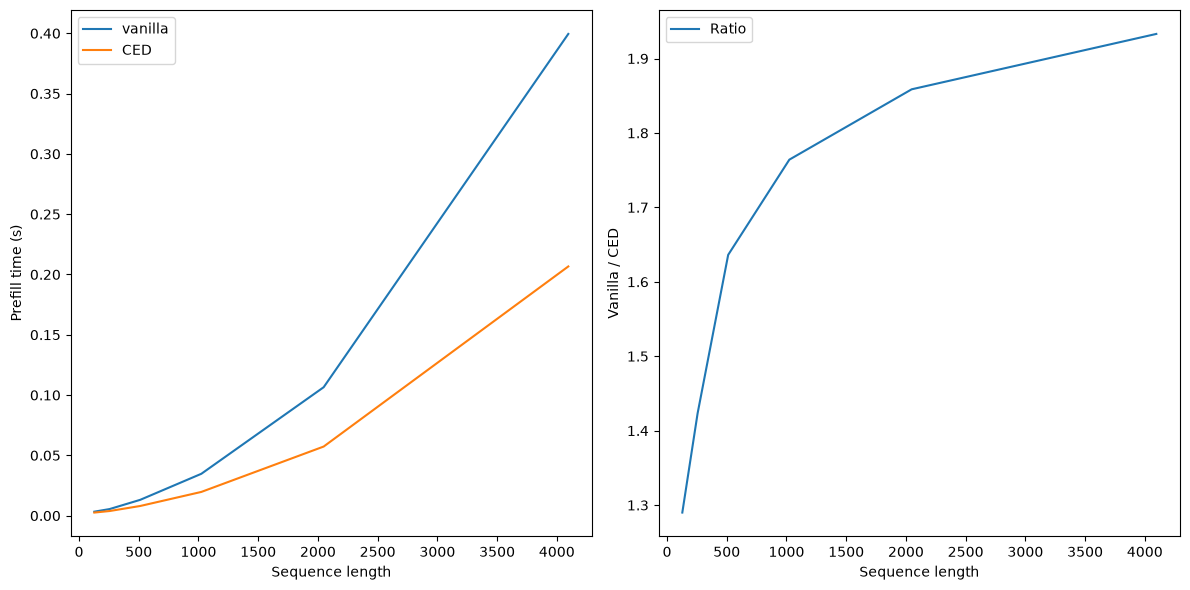

In [12]:
import time
import torch
from matplotlib import pyplot as plt

block_size = 256

van_model = VanillaTransformer(vocab_size, d_emb, n_heads, n_layers, block_size).to(device)
ced_model = Transformer(vocab_size, d_emb, n_heads, n_layers, block_size).to(device)


@torch.no_grad()
def time_prefill(m, batch_s, seq_len, warmup=5, trials=10):
    m.eval()
    ids = torch.randint(0, vocab_size, (batch_s, seq_len), device=device)

    for _ in range(warmup):
        m.prefill(ids)
    torch.mps.synchronize()

    start = time.time()
    for _ in range(trials):
        m.prefill(ids)
    torch.mps.synchronize()

    return (time.time() - start) / trials


seq_lens = [2**i for i in range(7, 13)] 
van_times = []
ced_times = []
ratios = []
for seq_len in seq_lens:
    van_times.append(time_prefill(van_model, 4, seq_len))
    ced_times.append(time_prefill(ced_model, 4, seq_len))
    ratios.append(van_times[-1] / ced_times[-1])
    print(f"seq_len {seq_len:5d} | vanilla {van_times[-1]*1e3:7.1f} ms | CED {ced_times[-1]*1e3:7.1f} ms | {van_times[-1]/ced_times[-1]:.2f}x")
    torch.mps.empty_cache()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].plot(seq_lens, van_times, label="vanilla")
axes[0].plot(seq_lens, ced_times, label="CED")
axes[0].set_xlabel("Sequence length")
axes[0].set_ylabel("Prefill time (s)")
axes[0].legend()

axes[1].plot(seq_lens, ratios, label="Ratio")
axes[1].set_xlabel("Sequence length")
axes[1].set_ylabel("Vanilla / CED")
axes[1].legend()

plt.tight_layout()
plt.show()
